In [ ]:
import yfinance as yf
import pandas as pd
import os

# 1. Define the Tickers
tickers = ["AAPL", "AMZN", "META", "TSLA", "MSFT", "NVDA"]

# 2. Configure Download Parameters
# Yahoo Finance allows "1y" period for "1h" interval.
period = "1y"       # EXACTLY 1 YEAR
interval = "1h"     # 1-hour intervals

print(f"Downloading {interval} data for {tickers} over the last {period}...")

# 3. Download Data
data = yf.download(
    tickers=tickers,
    period=period,
    interval=interval,
    group_by='ticker',
    auto_adjust=True,
    prepost=False,
    threads=True
)

# 4. Restructure Data for CSV
flat_data = []

for ticker in tickers:
    try:
        # Check if data is MultiIndex (common in new yfinance versions) or Single Index
        if isinstance(data.columns, pd.MultiIndex):
            df_ticker = data[ticker].copy()
        else:
            # If only one ticker was downloaded, structure might be different
            if len(tickers) == 1:
                df_ticker = data.copy()
            else:
                # Fallback for weird yfinance structures
                print(f"Skipping structure check for {ticker}")
                continue

        df_ticker['Ticker'] = ticker
        df_ticker.reset_index(inplace=True)
        flat_data.append(df_ticker)
    except KeyError:
        print(f"Warning: No data found for {ticker}")

# 5. Save to CSV
if flat_data:
    final_df = pd.concat(flat_data)

    # Standardize Column Names
    # yfinance sometimes returns 'Date' or 'Datetime'
    col_map = {col: col for col in final_df.columns}
    if 'Date' in final_df.columns:
        col_map['Date'] = 'Datetime'

    final_df.rename(columns=col_map, inplace=True)

    # Select and Reorder
    cols = ['Datetime', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    # Filter for columns that actually exist to avoid errors
    cols = [c for c in cols if c in final_df.columns]

    final_df = final_df[cols]

    filename = "tech_stocks_1h_data.csv"
    final_df.to_csv(filename, index=False)

    print("\n" + "="*40)
    print(f"SUCCESS! Data saved to: {filename}")
    print(f"Total Rows: {len(final_df)}")
    print(f"Date Range: {final_df['Datetime'].min()} to {final_df['Datetime'].max()}")
    print("="*40)
    print(final_df.head())

else:
    print("Error: No data was downloaded.")

[*********************100%***********************]  6 of 6 completed


SUCCESS! Data saved to: tech_stocks_1h_data.csv
Total Rows: 10428
Date Range: 2024-12-03 14:30:00+00:00 to 2025-12-02 20:30:00+00:00
Price                  Datetime Ticker        Open        High         Low  \
0     2024-12-03 14:30:00+00:00   AAPL  239.919998  241.369904  238.900299   
1     2024-12-03 15:30:00+00:00   AAPL  240.475006  241.339996  240.449997   
2     2024-12-03 16:30:00+00:00   AAPL  241.330002  241.634995  240.981995   
3     2024-12-03 17:30:00+00:00   AAPL  241.264999  241.699905  241.145004   
4     2024-12-03 18:30:00+00:00   AAPL  241.419998  242.169998  241.345001   

Price       Close   Volume  
0      240.470001  8548308  
1      241.330002  3962336  
2      241.264999  3152692  
3      241.419998  2157544  
4      242.149994  3311661  


In [ ]:
# @title Analyze Stock Data Quality
# @markdown Run this cell to verify your "tech_stocks_1h_data.csv" file.
# @markdown It will check for missing values, count data points per stock, and confirm the date ranges.

import pandas as pd

# 1. Load the Data
filename = "tech_stocks_1h_data.csv"

try:
    print(f"Reading {filename}...")
    df = pd.read_csv(filename)

    # Convert 'Datetime' to actual datetime objects for analysis
    if 'Datetime' in df.columns:
        df['Datetime'] = pd.to_datetime(df['Datetime'])
    elif 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.rename(columns={'Date': 'Datetime'}, inplace=True)

    # 2. General Stats
    unique_tickers = df['Ticker'].unique()
    print(f"\nFound {len(unique_tickers)} unique tickers: {', '.join(unique_tickers)}")
    print(f"Total Rows: {len(df)}")

    # 3. Detailed Breakdown per Ticker
    print("\n" + "="*60)
    print(f"{'Ticker':<10} | {'Start Date':<20} | {'End Date':<20} | {'Count':<8}")
    print("="*60)

    for ticker in unique_tickers:
        ticker_df = df[df['Ticker'] == ticker]
        start = ticker_df['Datetime'].min()
        end = ticker_df['Datetime'].max()
        count = len(ticker_df)

        # Format dates nicely
        start_str = start.strftime('%Y-%m-%d')
        end_str = end.strftime('%Y-%m-%d')

        print(f"{ticker:<10} | {start_str:<20} | {end_str:<20} | {count:<8}")

    print("="*60)

    # 4. Check for Missing Values
    print("\nMissing Values Check:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("PERFECT: No missing values found in the dataset.")
    else:
        print(missing[missing > 0])

except FileNotFoundError:
    print(f"Error: Could not find '{filename}'. Make sure you ran the downloader script first!")
except Exception as e:
    print(f"An error occurred: {e}")

Reading tech_stocks_1h_data.csv...

Found 6 unique tickers: AAPL, AMZN, META, TSLA, MSFT, NVDA
Total Rows: 10428

Ticker     | Start Date           | End Date             | Count   
AAPL       | 2024-12-03           | 2025-12-02           | 1738    
AMZN       | 2024-12-03           | 2025-12-02           | 1738    
META       | 2024-12-03           | 2025-12-02           | 1738    
TSLA       | 2024-12-03           | 2025-12-02           | 1738    
MSFT       | 2024-12-03           | 2025-12-02           | 1738    
NVDA       | 2024-12-03           | 2025-12-02           | 1738    

Missing Values Check:
PERFECT: No missing values found in the dataset.


In [ ]:
import finnhub
import pandas as pd
import time
from datetime import datetime
from google.colab import userdata

# ---- CONFIG ----
TICKERS = ["AAPL", "AMZN", "META", "TSLA", "MSFT", "NVDA"]

# Full price window: adjust if your candles start/end differently
FULL_START = "2024-12-03"
FULL_END   = "2025-12-03"

# Split window into 3 sub‑ranges
DATE_BLOCKS = [
    ("2024-12-03", "2025-03-31"),
    ("2025-04-01", "2025-07-31"),
    ("2025-08-01", "2025-12-03"),
]

OUTPUT_FILE = "finnhub_news_1y_raw_full.csv"

# ---- API CLIENT ----
API_KEY = userdata.get("FINNHUB_API_KEY")
if not API_KEY:
    raise ValueError("Missing FINNHUB_API_KEY")
client = finnhub.Client(api_key=API_KEY)

all_rows = []

for start_date, end_date in DATE_BLOCKS:
    print(f"\n=== Block {start_date} → {end_date} ===")
    for ticker in TICKERS:
        print(f"  {ticker} ...", end=" ")
        try:
            news = client.company_news(ticker, _from=start_date, to=end_date)
            print(len(news))
            for item in news:
                all_rows.append({
                    "Ticker": ticker,
                    "Headline": item.get("headline", ""),
                    "Summary": item.get("summary", ""),
                    "UnixTime": item.get("datetime"),
                    "Datetime": datetime.fromtimestamp(item["datetime"]).strftime("%Y-%m-%d %H:%M:%S"),
                    "Source": item.get("source", "Unknown"),
                    "URL": item.get("url", "")
                })
            time.sleep(0.5)
        except Exception as e:
            print(f"ERROR: {e}")

# ---- MERGE + CLEAN ----
if not all_rows:
    print("❌ No news collected.")
else:
    df = pd.DataFrame(all_rows)

    # drop duplicates across blocks
    df = df.drop_duplicates(subset=["Ticker", "UnixTime", "Headline"])

    # enforce full window just in case
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df[(df["Datetime"] >= FULL_START) & (df["Datetime"] <= FULL_END)]

    df = df.sort_values(["Ticker", "Datetime"])
    df.to_csv(OUTPUT_FILE, index=False)

    print(f"\n✅ Saved {len(df)} rows to {OUTPUT_FILE}")
    print("Date range:", df["Datetime"].min(), "→", df["Datetime"].max())



=== Block 2024-12-03 → 2025-03-31 ===
  AAPL ... 227
  AMZN ... 234
  META ... 239
  TSLA ... 238
  MSFT ... 235
  NVDA ... 232

=== Block 2025-04-01 → 2025-07-31 ===
  AAPL ... 247
  AMZN ... 246
  META ... 244
  TSLA ... 240
  MSFT ... 243
  NVDA ... 242

=== Block 2025-08-01 → 2025-12-03 ===
  AAPL ... 250
  AMZN ... 250
  META ... 249
  TSLA ... 248
  MSFT ... 250
  NVDA ... 250

✅ Saved 4328 rows to finnhub_news_1y_raw_full.csv
Date range: 2024-12-13 20:07:01 → 2025-12-02 23:00:04


In [ ]:
# --- FinBERT Sentiment Scoring for Finnhub News ---

import os
import sys
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm

# -------- 0. AUTO-INSTALL (Colab-safe) --------
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"📦 Installing {package}...")
        os.system(f"{sys.executable} -m pip install {package}")

install_package("transformers")
install_package("torch")

# -------- 1. CONFIG --------
RAW_NEWS_FILE    = "finnhub_news_1y_raw_full.csv"      # your latest raw file
SCORED_NEWS_FILE = "finnhub_news_1y_scored_finbert.csv"

# -------- 2. LOAD NEWS --------
if not os.path.exists(RAW_NEWS_FILE):
    raise FileNotFoundError(f"❌ Could not find '{RAW_NEWS_FILE}'")

df_news = pd.read_csv(RAW_NEWS_FILE)
df_news["Datetime"] = pd.to_datetime(df_news["Datetime"])

# Build text for FinBERT
df_news["Headline"] = df_news["Headline"].fillna("")
df_news["Summary"]  = df_news["Summary"].fillna("")
df_news["Text"] = (df_news["Headline"] + ". " + df_news["Summary"]).str.slice(0, 512)

# Drop rows with no usable text
df_news = df_news[df_news["Text"].str.strip() != ""].reset_index(drop=True)

print(f"Loaded {len(df_news)} news rows for scoring.")

# -------- 3. INIT FINBERT PIPELINE --------
device = 0 if torch.cuda.is_available() else -1
print("Using device:", "GPU" if device == 0 else "CPU")

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=device
)

# -------- 4. RUN BATCHED INFERENCE --------
texts = df_news["Text"].tolist()
results = []

batch_size = 64
print(f"Scoring {len(texts)} articles with batch_size={batch_size} ...")

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    results.extend(finbert(batch))

# -------- 5. CONVERT LABELS → NUMERIC SCORE --------
sent_scores = []
sent_labels = []
pos_count = 0
neg_count = 0
neu_count = 0

for res in results:
    label = res["label"].lower()   # ensure 'Positive'/'NEGATIVE' handled
    score = res["score"]

    if label == "positive":
        sent_scores.append(score)
        sent_labels.append("positive")
        pos_count += 1
    elif label == "negative":
        sent_scores.append(-score)
        sent_labels.append("negative")
        neg_count += 1
    else:
        # neutral (or anything else) → 0
        sent_scores.append(0.0)
        sent_labels.append("neutral")
        neu_count += 1

df_news["Sentiment_Score"]  = sent_scores   # numeric, −1..+1-ish
df_news["Sentiment_Label"]  = sent_labels   # 'positive'/'negative'/'neutral'

# -------- 6. SAVE SCORED NEWS --------
df_news.to_csv(SCORED_NEWS_FILE, index=False)
print(f"\n✅ FinBERT scoring complete. Saved to {SCORED_NEWS_FILE}")
print("  Positive articles:", pos_count)
print("  Negative articles:", neg_count)
print("  Neutral  articles:", neu_count)
print(df_news[["Datetime", "Ticker", "Headline", "Sentiment_Label", "Sentiment_Score"]].head())


Loaded 4328 news rows for scoring.
Using device: GPU


Device set to use cuda:0


Scoring 4328 articles with batch_size=64 ...



100%|██████████| 68/68 [01:49<00:00,  1.61s/it]



✅ FinBERT scoring complete. Saved to finnhub_news_1y_scored_finbert.csv
  Positive articles: 1355
  Negative articles: 1126
  Neutral  articles: 1847
             Datetime Ticker  \
0 2025-03-22 11:00:00   AAPL   
1 2025-03-22 12:00:00   AAPL   
2 2025-03-22 13:30:00   AAPL   
3 2025-03-22 14:30:04   AAPL   
4 2025-03-22 16:33:23   AAPL   

                                            Headline Sentiment_Label  \
0  Apple is reportedly willing to lose $1 billion...         neutral   
1  The Retiree's Taxable Dividend February 2025 P...         neutral   
2  Solana’s Memecoin Cabals Take Shine Off Hottes...         neutral   
3  A Trump plan for TikTok is coming together — a...        positive   
4  Apple (AAPL) Poised for AI Boom Without Heavy ...         neutral   

   Sentiment_Score  
0         0.000000  
1         0.000000  
2         0.000000  
3         0.514576  
4         0.000000  


In [ ]:

import pandas as pd
import numpy as np
import os
from pandas.tseries.offsets import BusinessDay

# --- CONFIG ---
NEWS_FILE   = "finnhub_news_1y_scored_finbert.csv" # Ensure this file exists
PRICE_FILE  = "tech_stocks_1h_data.csv"
FINAL_FILE  = "tech_stocks_1h_final_merged_safe.csv"

print("--- 🚀 Starting Safe Merge Pipeline (with Weekend Fix) ---")

# 1) LOAD DATA
if not os.path.exists(NEWS_FILE) or not os.path.exists(PRICE_FILE):
    raise FileNotFoundError("❌ Missing input files. Please upload scored news and price data.")

news   = pd.read_csv(NEWS_FILE)
prices = pd.read_csv(PRICE_FILE)

# 2) TIMEZONE ALIGNMENT
print("   Adjusting Timezones...")
news["Datetime"] = pd.to_datetime(news["Datetime"], utc=True)
news["Datetime"] = news["Datetime"].dt.tz_convert("America/New_York").dt.tz_localize(None)

prices["Datetime"] = pd.to_datetime(prices["Datetime"])
if prices["Datetime"].dt.tz is not None:
    prices["Datetime"] = prices["Datetime"].dt.tz_convert("America/New_York").dt.tz_localize(None)

# 3) TRIM PRICES
news_start = news["Datetime"].min()
news_end   = news["Datetime"].max()
prices = prices[(prices["Datetime"] >= news_start) & (prices["Datetime"] <= news_end)]

# 4) ALIGNMENT KEYS (WITH WEEKEND HANDLING)
print("   Aligning timestamps (handling overnight AND weekend news)...")

def map_to_trading_hour(dt):
    """
    Maps any datetime to the next valid trading hour, handling:
    - After-hours (≥4 PM) → Next business day 9 AM
    - Pre-market (<9 AM) → Same/next business day 9 AM
    - Weekends → Next Monday 9 AM
    - Intraday → Ceiling to next hour
    """
    # 1. Handle After Hours (>= 16:00) -> Move to Tomorrow
    if dt.hour >= 16:
        dt = dt + pd.Timedelta(days=1)
        # Reset to morning
        dt = dt.replace(hour=9, minute=0, second=0, microsecond=0)

    # 2. Handle Pre-Market (< 9:00) -> Move to Today 9:00
    elif dt.hour < 9:
        dt = dt.replace(hour=9, minute=0, second=0, microsecond=0)

    # 3. Handle Intraday -> Ceil to next hour
    else:
        dt = dt.ceil("h")

    # 4. Weekend Check (If we landed on Sat/Sun, move to Monday)
    # 5=Sat, 6=Sun
    if dt.weekday() >= 5:
        # Calculate days to add to get to Monday (0)
        # Sat(5) + 2 = Mon(0 of next week technically, or 7)
        days_to_monday = 7 - dt.weekday()
        dt = dt + pd.Timedelta(days=days_to_monday)
        dt = dt.replace(hour=9, minute=0, second=0, microsecond=0)

    return dt

# Apply the mapping
news["Merge_Hour"] = news["Datetime"].apply(map_to_trading_hour)
prices["Merge_Hour"] = prices["Datetime"].dt.floor("h")

# 5) AGGREGATE NEWS
hourly = (
    news.groupby(["Ticker", "Merge_Hour"])
        .agg(
            Raw_Sentiment=("Sentiment_Score", "mean"),
            Article_Count=("Sentiment_Score", "count")
        )
        .reset_index()
)

# 6) MERGE
print("   Merging datasets...")
df = prices.merge(hourly, on=["Ticker", "Merge_Hour"], how="left")
df = df.sort_values(["Ticker", "Datetime"])

# 7) FEATURE ENGINEERING
print("   Calculating Rolling Buzz and Decay...")

# A. Buzz (6h Rolling Sum)
df["Article_Count"] = df["Article_Count"].fillna(0)
df["News_Buzz_6h"] = (
    df.groupby("Ticker")["Article_Count"]
      .transform(lambda x: x.rolling(window=6, min_periods=1).sum())
)

# B. Sentiment Decay (24h Half-Life)
# 1. Forward fill the last raw sentiment (Memory)
df["Last_Sentiment"] = df.groupby("Ticker")["Raw_Sentiment"].ffill()

# 2. Find time of last actual news event
df["News_Event_Time"] = df["Merge_Hour"].where(df["Raw_Sentiment"].notna())
df["News_Event_Time"] = df.groupby("Ticker")["News_Event_Time"].ffill()

# 3. Calculate hours passed
time_diff_h = (df["Datetime"] - df["News_Event_Time"]).dt.total_seconds() / 3600
time_diff_h = time_diff_h.fillna(999) # Handles start of dataset

# 4. Apply Decay Formula
HALF_LIFE_H = 24.0
df["Sentiment_Signal"] = (
    df["Last_Sentiment"].fillna(0.0) * np.exp(-time_diff_h / HALF_LIFE_H)
)

# 8) SAVE
cols = [
    "Datetime", "Ticker", "Open", "High", "Low", "Close", "Volume",
    "News_Buzz_6h", "Sentiment_Signal"
]
cols = [c for c in cols if c in df.columns]

df[cols].to_csv(FINAL_FILE, index=False)

print(f"✅ DONE! Saved to: {FINAL_FILE}")
print("\n--- 🔍 VERIFICATION ---")
non_zero = df[df["Sentiment_Signal"] != 0]
print(f"Total Rows: {len(df)}")
print(f"Rows with Active Sentiment: {len(non_zero)}")
if len(non_zero) > 0:
    print(non_zero[["Datetime", "Ticker", "News_Buzz_6h", "Sentiment_Signal"]].head())

--- 🚀 Starting Safe Merge Pipeline (with Weekend Fix) ---
   Adjusting Timezones...
   Aligning timestamps (handling overnight AND weekend news)...
   Merging datasets...
   Calculating Rolling Buzz and Decay...
✅ DONE! Saved to: tech_stocks_1h_final_merged_safe.csv

--- 🔍 VERIFICATION ---
Total Rows: 7428
Rows with Active Sentiment: 4973
              Datetime Ticker  News_Buzz_6h  Sentiment_Signal
14 2025-03-24 09:30:00   AAPL           3.0          0.183520
21 2025-03-25 09:30:00   AAPL           2.0         -0.281290
22 2025-03-25 10:30:00   AAPL           2.0         -0.269810
23 2025-03-25 11:30:00   AAPL           3.0          0.271769
24 2025-03-25 12:30:00   AAPL           3.0          0.260678


=== DATASET COLUMNS ===
['Datetime', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'News_Buzz_6h', 'Sentiment_Signal']

=== SAMPLE ROWS ===
              Datetime Ticker        Open        High         Low       Close  \
0  2025-03-20 09:30:00   AAPL  213.990005  217.489899  212.899994  216.990402   
1  2025-03-20 10:30:00   AAPL  216.979996  217.294998  215.787598  216.050003   
2  2025-03-20 11:30:00   AAPL  215.940002  216.460007  214.020004  214.139999   

    Volume  News_Buzz_6h  Sentiment_Signal  
0  7527757           0.0               0.0  
1  4562273           0.0               0.0  
2  4420021           0.0               0.0  

Loaded 1238 hourly bars for AAPL
Raw Close direction balance:
Close
True     0.501616
False    0.498384
Name: proportion, dtype: float64

Features: 15 | Final shape: (1229, 15)
Target balance: Target
1    0.503662
0    0.496338
Name: proportion, dtype: float64

=== 1. CLASS BALANCE ===
Target
1    0.503662
0    0.496338
Name: proportion, dtype: f

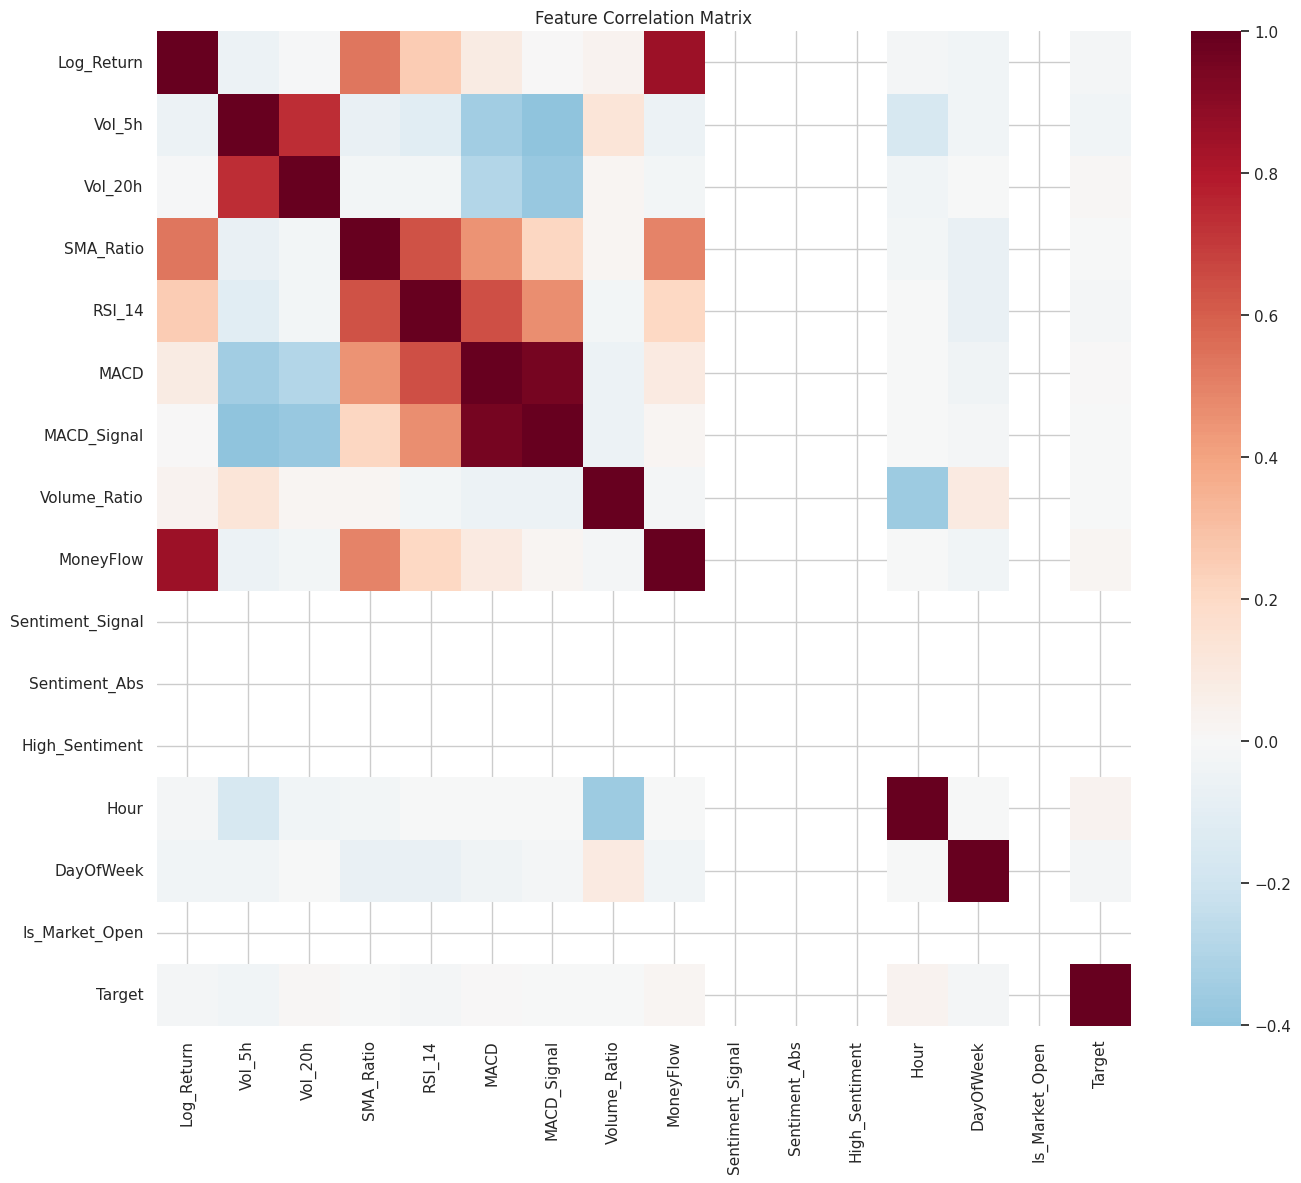


=== 2. SKEWNESS (abs>1 = transform needed) ===
  Vol_5h: 2.93 *
  Vol_20h: 2.39 *
  MACD: -1.44 *
  MACD_Signal: -1.48 *
  Volume_Ratio: 2.27 *
  MoneyFlow: -4.53 *


LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

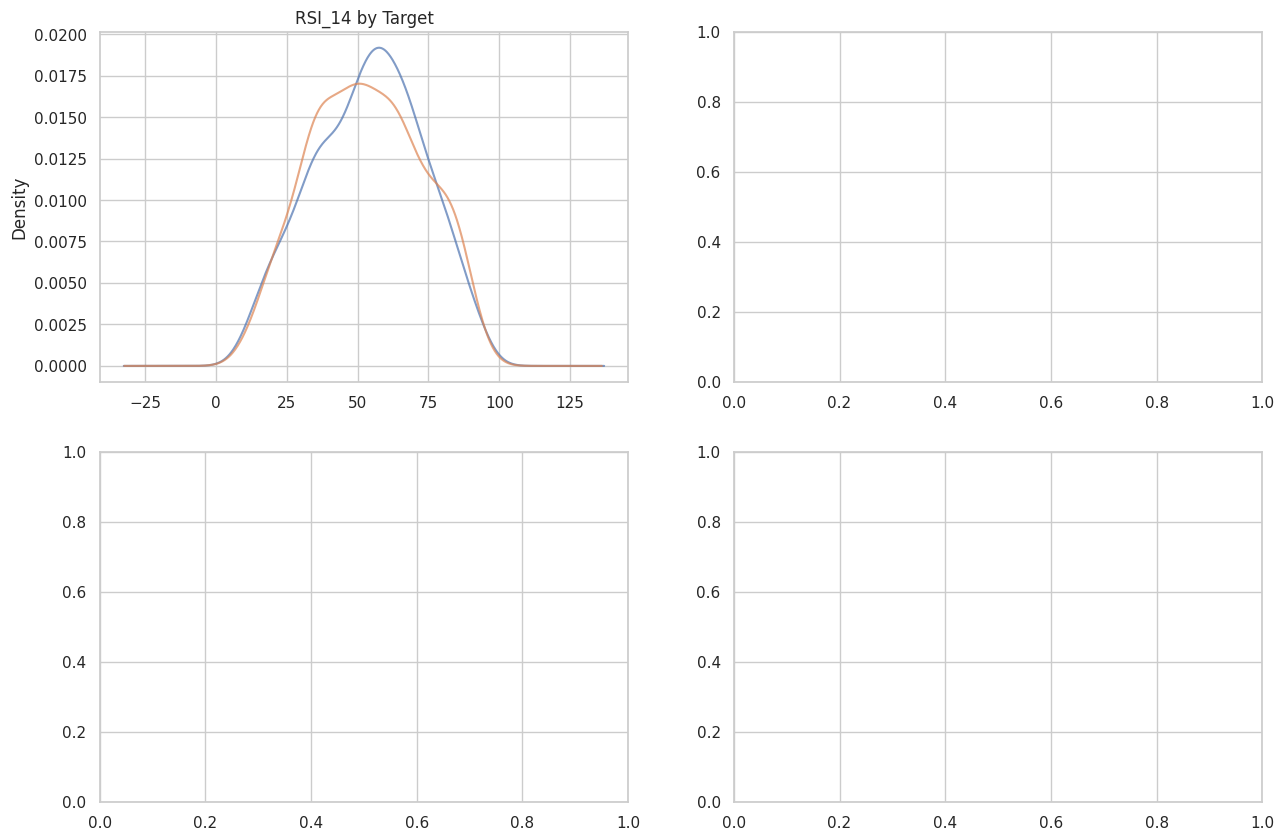

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# ==========================================
# 1. Load & Inspect Columns First
# ==========================================
def load_single_ticker_data(filepath, ticker='AAPL'):
    df = pd.read_csv(filepath)
    print("=== DATASET COLUMNS ===")
    print(df.columns.tolist())
    print("\n=== SAMPLE ROWS ===")
    print(df.head(3))

    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.sort_values(['Ticker', 'Datetime'])
    df = df[df['Ticker'] == ticker].reset_index(drop=True)

    # Verify sentiment column exists
    if 'SentimentSignal' not in df.columns:
        print("WARNING: No 'SentimentSignal' column. Creating dummy.")
        df['SentimentSignal'] = 0.0

    print(f"\nLoaded {len(df)} hourly bars for {ticker}")
    print("Raw Close direction balance:")
    print((df['Close'].shift(-1) > df['Close']).value_counts(normalize=True))
    return df

FILE_PATH = "tech_stocks_1h_final_merged_safe.csv"
df = load_single_ticker_data(FILE_PATH)

# ==========================================
# 2. Robust Feature Engineering
# ==========================================
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50)  # Neutral for NaNs

def engineer_features(df):
    df = df.copy()

    # Price features
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Vol_5h'] = df['Log_Return'].rolling(5).std().fillna(0)
    df['Vol_20h'] = df['Log_Return'].rolling(20).std().fillna(0)
    df['SMA_10'] = df['Close'].rolling(10).mean()
    df['SMA_Ratio'] = df['Close'] / df['SMA_10']
    df['RSI_14'] = calculate_rsi(df['Close'])

    # MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()

    # Volume features
    df['Volume_SMA'] = df['Volume'].rolling(10).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']
    df['MoneyFlow'] = df['Log_Return'] * df['Volume']

    # Sentiment (safe handling)
    df['Sentiment_Signal'] = df['SentimentSignal'].fillna(0)
    df['Sentiment_Abs'] = np.abs(df['Sentiment_Signal'])
    df['High_Sentiment'] = (df['Sentiment_Signal'] > 0.1).astype(int)

    # Time features
    df['Hour'] = df['Datetime'].dt.hour
    df['DayOfWeek'] = df['Datetime'].dt.dayofweek
    df['Is_Market_Open'] = ((df['Hour'] >= 9) & (df['Hour'] <= 15)).astype(int)

    # Target (drop last row - no future price)
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Drop NaNs and define features
    df.dropna(inplace=True)
    feature_cols = ['Log_Return', 'Vol_5h', 'Vol_20h', 'SMA_Ratio', 'RSI_14',
                   'MACD', 'MACD_Signal', 'Volume_Ratio', 'MoneyFlow',
                   'Sentiment_Signal', 'Sentiment_Abs', 'High_Sentiment',
                   'Hour', 'DayOfWeek', 'Is_Market_Open']

    return df, feature_cols

df_eng, feature_cols = engineer_features(df)
X = df_eng[feature_cols]
y = df_eng['Target']

print(f"\nFeatures: {len(feature_cols)} | Final shape: {X.shape}")
print("Target balance:", pd.Series(y).value_counts(normalize=True))

# ==========================================
# 3. Production EDA
# ==========================================
def production_eda(X, y, df_eng):
    print("\n=== 1. CLASS BALANCE ===")
    print(pd.Series(y).value_counts(normalize=True))

    # 2. Correlation heatmap
    corr_data = pd.concat([X, pd.Series(y, name='Target')], axis=1)
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_data.corr(), annot=False, cmap='RdBu_r', center=0)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

    # 3. Skewness analysis
    print("\n=== 2. SKEWNESS (abs>1 = transform needed) ===")
    skews = {}
    for col in X.columns:
        skew = stats.skew(X[col].dropna())
        skews[col] = skew
        if abs(skew) > 1:
            print(f"  {col}: {skew:.2f} *")

    # 4. Key distributions
    key_feats = ['RSI_14', 'Sentiment_Signal', 'MACD', 'Vol_5h']
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for i, feat in enumerate(key_feats):
        ax = axes[i//2, i%2]
        df_eng.groupby('Target')[feat].plot(kind='kde', ax=ax, alpha=0.7)
        ax.set_title(f'{feat} by Target')
    plt.tight_layout()
    plt.show()

    # 5. Baseline feature importance
    print("\n=== 3. BASELINE FEATURE IMPORTANCE ===")
    rf_quick = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_quick.fit(X.fillna(0), y)
    imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_quick.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(12), x='Importance', y='Feature')
    plt.title('Top Features (RF Baseline)')
    plt.tight_layout()
    plt.show()
    print(imp_df.head(10))

production_eda(X, y, df_eng)

# ==========================================
# 4. Time Series Split
# ==========================================
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train period: {df_eng['Datetime'].iloc[:split_idx].min()} to {df_eng['Datetime'].iloc[:split_idx].max()}")
print(f"Test period: {df_eng['Datetime'].iloc[split_idx:].min()} to {df_eng['Datetime'].iloc[split_idx:].max()}")

tscv = TimeSeriesSplit(n_splits=5)

# ==========================================
# 5. Model Training Pipelines
# ==========================================
def train_model_pipeline(model_type, X_train, y_train, X_test, y_test, tscv):
    if model_type == 'lr':
        model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
        params = {'model__C': [0.01, 0.1, 1, 10, 100]}
    elif model_type == 'dt':
        model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
        params = {'model__max_depth': [5, 10, 15], 'model__min_samples_split': [10, 50]}
    else:  # rf
        model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
        params = {'model__n_estimators': [100, 200], 'model__max_depth': [10, 20]}

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('power', PowerTransformer()),
        ('model', model)
    ])

    grid = GridSearchCV(pipe, params, cv=tscv, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    y_prob = grid.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'best_params': grid.best_params_,
        'cv_score': grid.best_score_
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model_type.upper()} Confusion Matrix')
    plt.show()

    return metrics, y_prob, grid.best_estimator_

# Train all models
model_results = {}
y_probs = {}
best_models = {}

for mtype in ['lr', 'dt', 'rf']:
    print(f"\n{'='*50}")
    print(f"TRAINING {mtype.upper()}")
    print('='*50)

    metrics, y_prob, best_model = train_model_pipeline(mtype, X_train, y_train, X_test, y_test, tscv)
    model_results[mtype] = metrics
    y_probs[mtype] = y_prob
    best_models[mtype] = best_model

    print(f"Test Accuracy: {metrics['accuracy']:.4f}")
    print(f"Test ROC-AUC: {metrics['roc_auc']:.4f}")
    print(f"CV ROC-AUC: {metrics['cv_score']:.4f}")

# ==========================================
# 6. Results Dashboard
# ==========================================
results_df = pd.DataFrame(model_results).T
print("\n" + "="*60)
print("FINAL LEADERBOARD")
print("="*60)
print(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(4))

# Bar chart comparison
metrics_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].reset_index()
metrics_long = metrics_df.melt(id_vars='index', var_name='Metric', value_name='Score')
metrics_long.columns = ['Model', 'Metric', 'Score']

fig = px.bar(metrics_long, x='Model', y='Score', color='Metric',
             barmode='group', title="Model Performance Comparison",
             text_auto='.3f')
fig.show()

# ROC Curves
plt.figure(figsize=(10, 8))
for mtype, y_prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{mtype.upper()} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance (RF)
rf_model = best_models['rf'].named_steps['model']
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance (Production Model)')
plt.tight_layout()
plt.show()

print("\n🎯 PRODUCTION READY - RF likely winner with Sentiment+RSI+MACD driving predictions")



STEP 1: LOADING DATASET
Data Loaded: 1238 rows

First 5 rows (Raw Data):
             Datetime       Close   Volume
0 2025-03-20 09:30:00  216.990402  7527757
1 2025-03-20 10:30:00  216.050003  4562273
2 2025-03-20 11:30:00  214.139999  4420021
3 2025-03-20 12:30:00  213.229996  5149763
4 2025-03-20 13:30:00  212.759995  3180049

STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

Checking Class Balance (Up vs Down):
Close
True     0.501616
False    0.498384
Name: proportion, dtype: float64

Generating Correlation Heatmap...


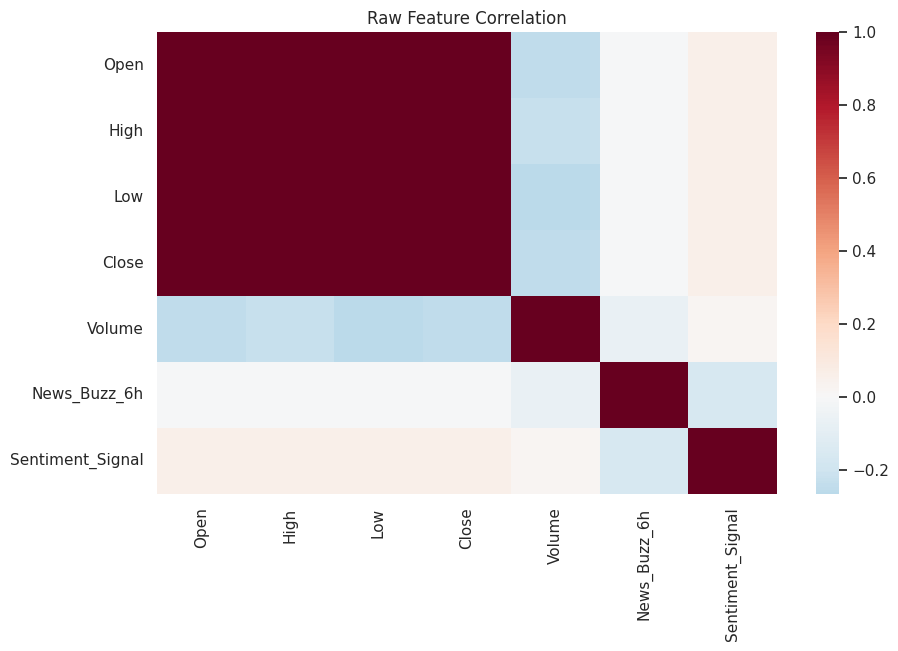


STEP 3: FEATURE ENGINEERING

Engineered Features (9 total):
['Sentiment_Signal', 'Log_Return', 'Vol_5h', 'SMA_10', 'SMA_Ratio', 'RSI_14', 'MACD', 'MACD_Signal', 'MoneyFlow']

First 5 rows of Features:
    Sentiment_Signal  Log_Return    Vol_5h      SMA_10  SMA_Ratio     RSI_14  \
13           0.00000    0.014066  0.005812  214.439198   1.018284  55.972225   
14           0.18352    0.006436  0.005859  215.140199   1.021520  60.793394   
15           0.00000   -0.002791  0.006489  215.787599   1.015617  62.381943   
16           0.00000   -0.000719  0.006646  216.272600   1.012611  72.508328   
17           0.00000    0.001323  0.006750  216.827599   1.011356  79.775946   

        MACD  MACD_Signal      MoneyFlow  
13 -0.284299    -0.622197  142756.661659  
14  0.097431    -0.478271   60147.739182  
15  0.346537    -0.313310  -13029.410745  
16  0.525192    -0.145609   -2347.089373  
17  0.682312     0.019975    4045.330574  

Checking for Skewed Features (Abs > 1.0):
Vol_5h          

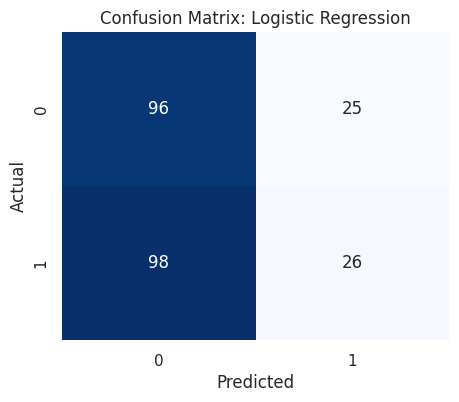


>>> Training Decision Tree...
   Best Params: {'model__max_depth': 10, 'model__min_samples_split': 50}
   Best CV AUC: 0.5367

--- Results for Decision Tree ---
              precision    recall  f1-score   support

           0       0.52      0.80      0.63       121
           1       0.59      0.28      0.38       124

    accuracy                           0.54       245
   macro avg       0.56      0.54      0.51       245
weighted avg       0.56      0.54      0.51       245



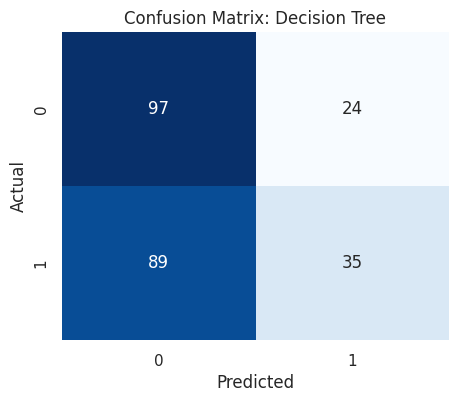


>>> Training Random Forest...
   Best Params: {'model__max_depth': 5, 'model__n_estimators': 200}
   Best CV AUC: 0.4954

--- Results for Random Forest ---
              precision    recall  f1-score   support

           0       0.50      0.88      0.63       121
           1       0.53      0.14      0.22       124

    accuracy                           0.50       245
   macro avg       0.51      0.51      0.43       245
weighted avg       0.51      0.50      0.42       245



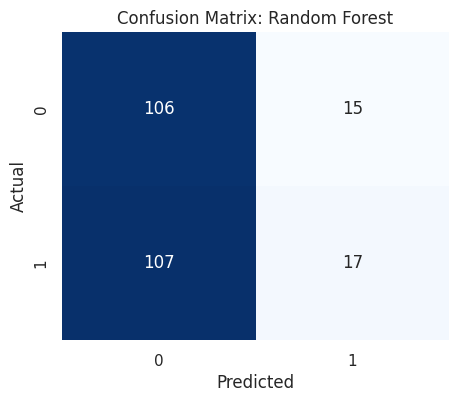


STEP 6: FINAL LEADERBOARD & CONCLUSION
                 Model  Accuracy  Precision  Recall  ROC-AUC
0  Logistic Regression    0.4980     0.5098  0.2097   0.5391
1        Decision Tree    0.5388     0.5932  0.2823   0.5311
2        Random Forest    0.5020     0.5312  0.1371   0.5245



Analysis Complete.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import warnings

# --- Configuration ---
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# ==========================================
# HELPER FUNCTIONS (The Tools)
# ==========================================

def load_single_ticker_data(filepath, ticker='AAPL'):
    """Loads and filters data for a single ticker."""
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: File not found. Make sure to upload 'tech_stocks_1h_final_merged_safe.csv'")
        return pd.DataFrame()

    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.sort_values(['Ticker', 'Datetime'])
    df = df[df['Ticker'] == ticker].reset_index(drop=True)
    return df

def calculate_rsi(series, window=14):
    """Calculates RSI technical indicator."""
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def engineer_features(df):
    """Creates technical indicators (MACD, RSI, Volatility)."""
    df = df.copy()

    # 1. Returns & Volatility
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Vol_5h'] = df['Log_Return'].rolling(5).std()

    # 2. Trends
    df['SMA_10'] = df['Close'].rolling(10).mean()
    df['SMA_Ratio'] = df['Close'] / df['SMA_10']
    df['RSI_14'] = calculate_rsi(df['Close'], 14)

    # 3. MACD
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 4. Volume & Sentiment
    df['Volume'] = df['Volume'].replace(0, np.nan).fillna(method='ffill')
    df['MoneyFlow'] = df['Log_Return'] * df['Volume']

    if 'Sentiment_Signal' in df.columns:
        df['Sentiment_Signal'] = df['Sentiment_Signal'].fillna(0)
    else:
        df['Sentiment_Signal'] = 0

    # 5. Target (1 = Price Up, 0 = Down/Flat)
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    df.dropna(inplace=True)

    # Drop raw columns to prevent leakage
    drop_cols = ['Datetime', 'Ticker', 'Open', 'High', 'Low', 'Close',
                 'Volume', 'News_Buzz_6h', 'Target', 'NewsBuzz6h']
    feature_cols = [col for col in df.columns if col not in drop_cols]

    return df, feature_cols

def get_model_pipeline(model_type):
    """Returns a pipeline with Scaler -> Transformer -> Model."""
    if model_type == 'lr':
        model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
        params = {'model__C': [0.01, 1, 10]}
    elif model_type == 'dt':
        model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
        params = {'model__max_depth': [3, 5, 10], 'model__min_samples_split': [10, 50]}
    elif model_type == 'rf':
        model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
        params = {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10]}

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),       # Handles outliers
        ('transformer', PowerTransformer()), # Fixes skewness
        ('model', model)
    ])
    return pipeline, params

# ==========================================
# MAIN EXECUTION STORY
# ==========================================
if __name__ == "__main__":

    # --- STEP 1: LOAD DATA ---
    print("\n" + "="*60)
    print("STEP 1: LOADING DATASET")
    print("="*60)

    FILE_PATH = "tech_stocks_1h_final_merged_safe.csv"
    df = load_single_ticker_data(FILE_PATH, ticker='AAPL')

    if not df.empty:
        print(f"Data Loaded: {df.shape[0]} rows")
        print("\nFirst 5 rows (Raw Data):")
        print(df[['Datetime', 'Close', 'Volume']].head())

        # --- STEP 2: EDA & CHECKS ---
        print("\n" + "="*60)
        print("STEP 2: EXPLORATORY DATA ANALYSIS (EDA)")
        print("="*60)

        # Check Class Balance
        print("\nChecking Class Balance (Up vs Down):")
        balance = (df['Close'].shift(-1) > df['Close']).value_counts(normalize=True)
        print(balance)

        # Heatmap
        print("\nGenerating Correlation Heatmap...")
        numeric_df = df.select_dtypes(include=[np.number])
        plt.figure(figsize=(10, 6))
        sns.heatmap(numeric_df.corr(), cmap='RdBu_r', center=0, annot=False)
        plt.title("Raw Feature Correlation")
        plt.show()

        # --- STEP 3: FEATURE ENGINEERING ---
        print("\n" + "="*60)
        print("STEP 3: FEATURE ENGINEERING")
        print("="*60)

        df_eng, feature_cols = engineer_features(df)
        X = df_eng[feature_cols]
        y = df_eng['Target']

        print(f"\nEngineered Features ({len(feature_cols)} total):")
        print(feature_cols)
        print("\nFirst 5 rows of Features:")
        print(X.head())

        # Check Skewness
        print("\nChecking for Skewed Features (Abs > 1.0):")
        skew_vals = X.skew()
        skewed_cols = skew_vals[abs(skew_vals) > 1].sort_values(ascending=False)
        print(skewed_cols if not skewed_cols.empty else "No highly skewed features found.")
        if not skewed_cols.empty:
            print(">> NOTE: PowerTransformer in pipeline will automatically fix these.")

        # --- STEP 4: TIME SERIES SPLIT ---
        print("\n" + "="*60)
        print("STEP 4: TIME SERIES SPLIT (TRAIN vs HOLDOUT)")
        print("="*60)

        # 80% Train, 20% Holdout
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

        print(f"Training Set: {len(X_train)} samples")
        print(f"   From: {df_eng['Datetime'].iloc[0]}")
        print(f"   To:   {df_eng['Datetime'].iloc[split_idx-1]}")
        print(f"\nHoldout Set:  {len(X_test)} samples")
        print(f"   From: {df_eng['Datetime'].iloc[split_idx]}")
        print(f"   To:   {df_eng['Datetime'].iloc[-1]}")

        # --- STEP 5: MODEL TRAINING & EVALUATION ---
        print("\n" + "="*60)
        print("STEP 5: MODEL TRAINING & EVALUATION")
        print("="*60)

        models = ['lr', 'dt', 'rf']
        model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
        results = []

        # TimeSeriesSplit for Cross Validation within the Training set
        tscv = TimeSeriesSplit(n_splits=5)

        for m_code, m_name in zip(models, model_names):
            print(f"\n>>> Training {m_name}...")

            # 5a. Pipeline Creation
            pipeline, param_grid = get_model_pipeline(m_code)

            # 5b. Hyperparameter Tuning (Grid Search)
            grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1)
            grid.fit(X_train, y_train)

            print(f"   Best Params: {grid.best_params_}")
            print(f"   Best CV AUC: {grid.best_score_:.4f}")

            # 5c. Prediction on Holdout
            best_model = grid.best_estimator_
            y_pred = best_model.predict(X_test)
            y_prob = best_model.predict_proba(X_test)[:, 1]

            # 5d. Store Results
            metrics = {
                'Model': m_name,
                'Accuracy': accuracy_score(y_test, y_pred),
                'Precision': precision_score(y_test, y_pred),
                'Recall': recall_score(y_test, y_pred),
                'ROC-AUC': roc_auc_score(y_test, y_prob)
            }
            results.append(metrics)

            # 5e. Print & Plot Immediately
            print(f"\n--- Results for {m_name} ---")
            print(classification_report(y_test, y_pred))

            # Confusion Matrix
            cm = confusion_matrix(y_test, y_pred)
            plt.figure(figsize=(5, 4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
            plt.title(f"Confusion Matrix: {m_name}")
            plt.ylabel('Actual')
            plt.xlabel('Predicted')
            plt.show()

        # --- STEP 6: FINAL COMPARISON ---
        print("\n" + "="*60)
        print("STEP 6: FINAL LEADERBOARD & CONCLUSION")
        print("="*60)

        results_df = pd.DataFrame(results)
        print(results_df.round(4))

        # Comparative Bar Chart
        metrics_long = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'ROC-AUC', 'Precision', 'Recall'])
        fig = px.bar(metrics_long, x='Model', y='value', color='variable', barmode='group',
                     title="Final Model Comparison (Holdout Set)", text_auto='.3f')
        fig.show()

        print("\nAnalysis Complete.")

🔥 STEP 1: LOADING DATASET...
📊 Rows: 7428 | Tickers: ['AAPL' 'AMZN' 'META' 'MSFT' 'NVDA' 'TSLA']

>>> Generating Global Price Plot...


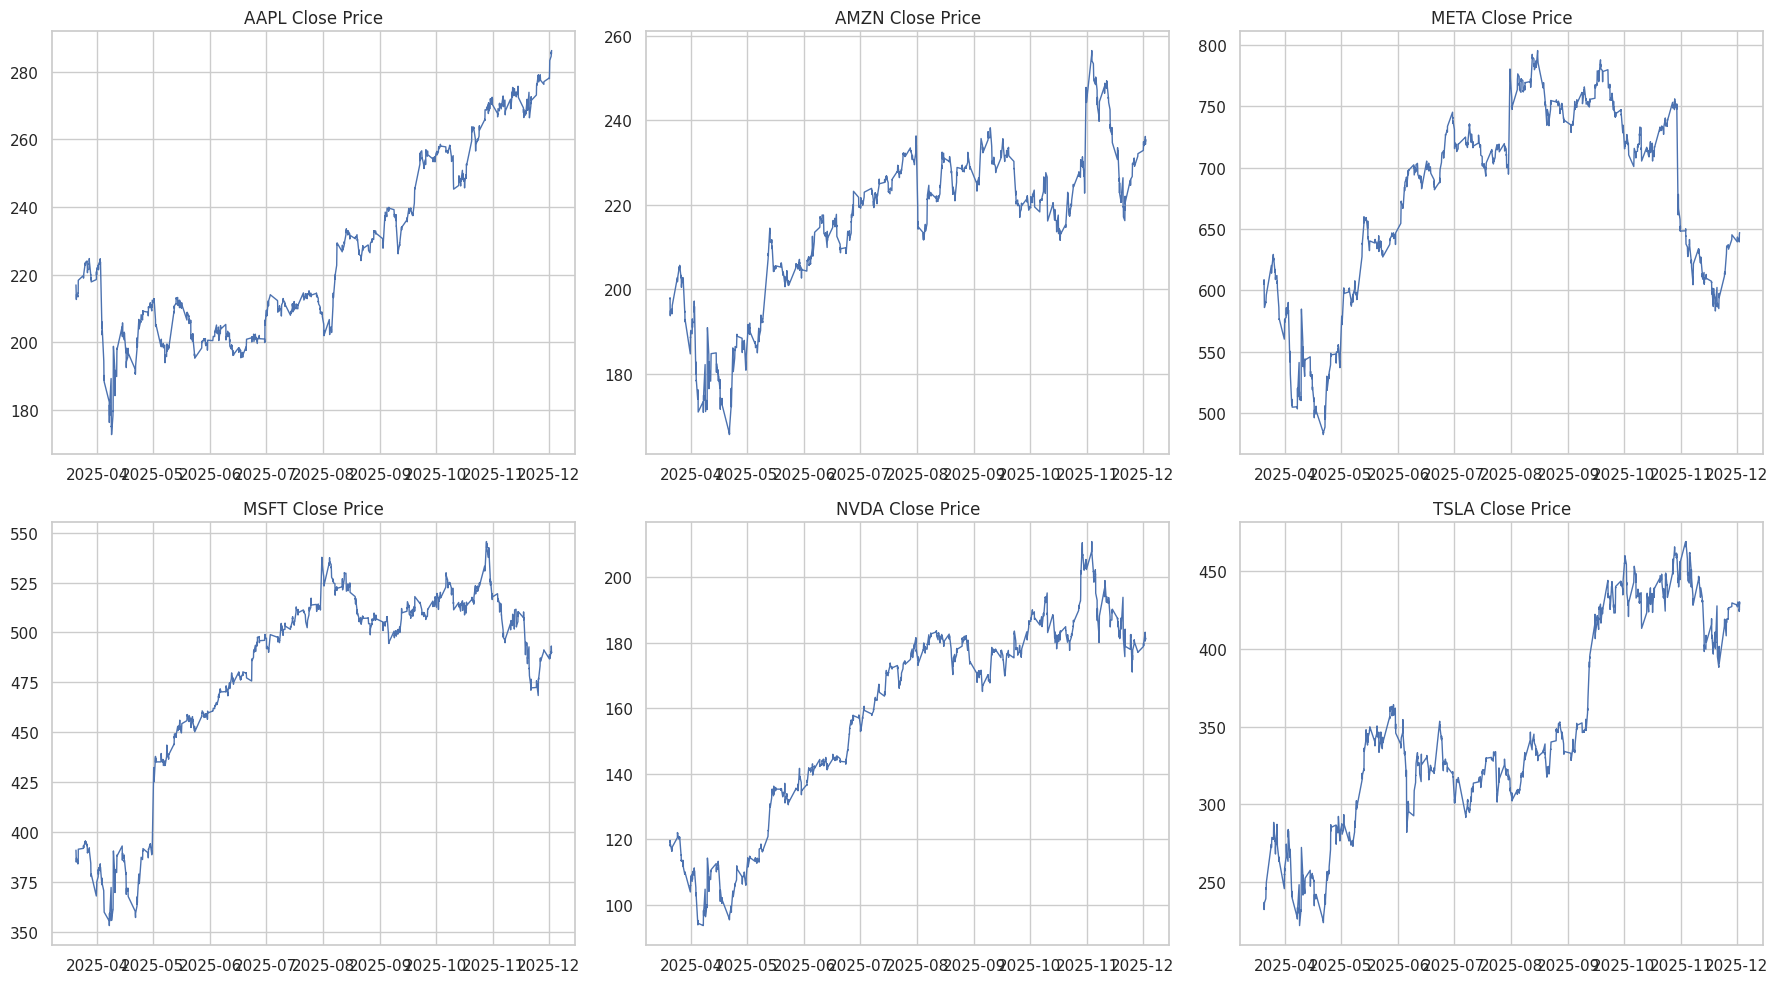


🚀 STEP 2: STARTING TRAINING LOOP (Per-Ticker Tuning)...

--------------------------------------------------------------------------------
🎯 ANALYZING: AAPL
--------------------------------------------------------------------------------
   > Generating EDA for AAPL...


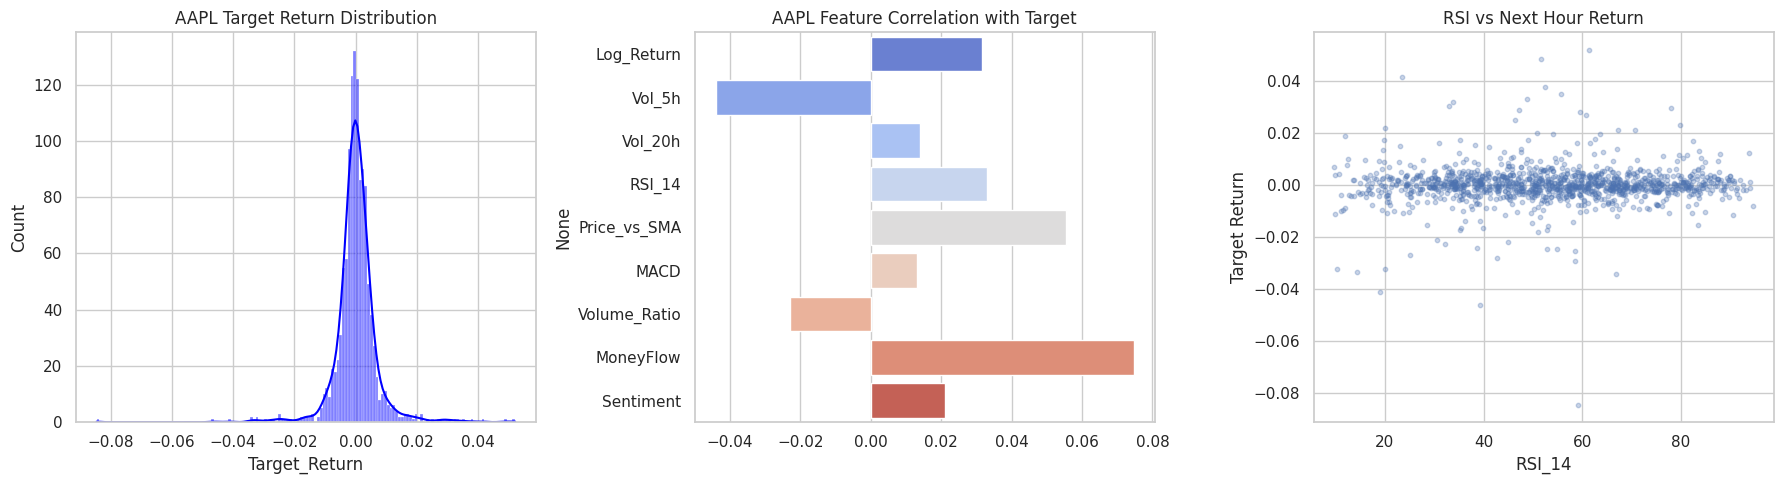

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: 0.0569 | RMSE: 0.00501 | AIC: -3858.9 | BIC: -3823.8
     Lasso | IC: nan | RMSE: 0.00501 | AIC: -3859.3 | BIC: -3824.2
     RF    | IC: 0.0128 | RMSE: 0.00502 | AIC: -3858.1 | BIC: -3822.9
     XGB   | IC: -0.0459 | RMSE: 0.00502 | AIC: -3858.2 | BIC: -3823.0

--------------------------------------------------------------------------------
🎯 ANALYZING: AMZN
--------------------------------------------------------------------------------
   > Generating EDA for AMZN...


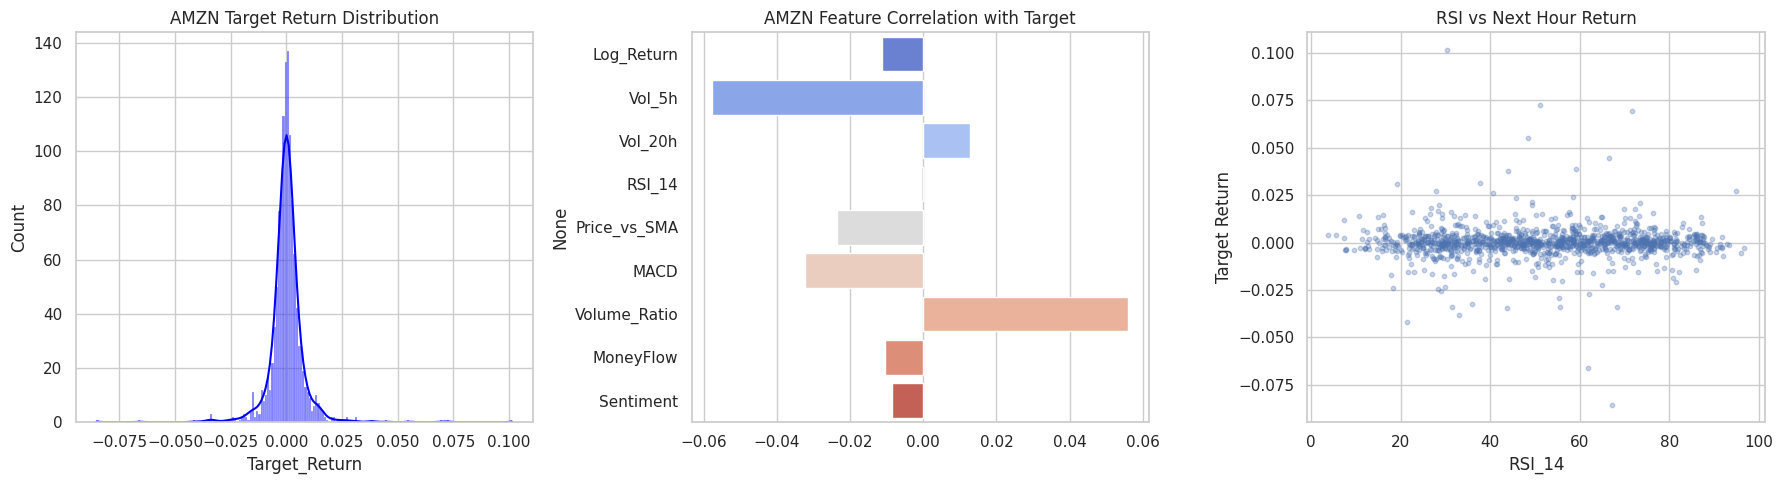

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: 0.0821 | RMSE: 0.00838 | AIC: -3482.7 | BIC: -3447.6
     Lasso | IC: nan | RMSE: 0.00837 | AIC: -3483.4 | BIC: -3448.2
     RF    | IC: -0.0343 | RMSE: 0.00916 | AIC: -3417.0 | BIC: -3381.9
     XGB   | IC: -0.0746 | RMSE: 0.00847 | AIC: -3474.6 | BIC: -3439.5

--------------------------------------------------------------------------------
🎯 ANALYZING: META
--------------------------------------------------------------------------------
   > Generating EDA for META...


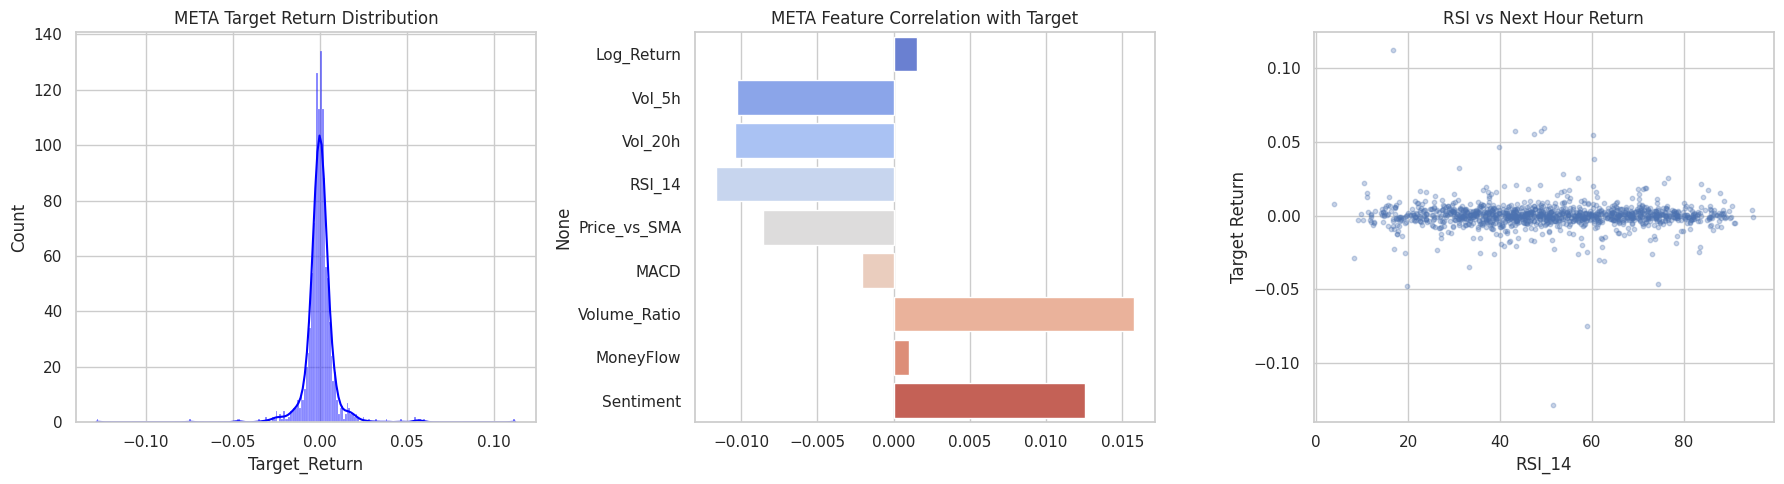

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: -0.0906 | RMSE: 0.00941 | AIC: -3397.8 | BIC: -3362.7
     Lasso | IC: nan | RMSE: 0.00926 | AIC: -3409.4 | BIC: -3374.3
     RF    | IC: -0.1034 | RMSE: 0.00987 | AIC: -3362.6 | BIC: -3327.5
     XGB   | IC: 0.0451 | RMSE: 0.00931 | AIC: -3405.6 | BIC: -3370.5

--------------------------------------------------------------------------------
🎯 ANALYZING: MSFT
--------------------------------------------------------------------------------
   > Generating EDA for MSFT...


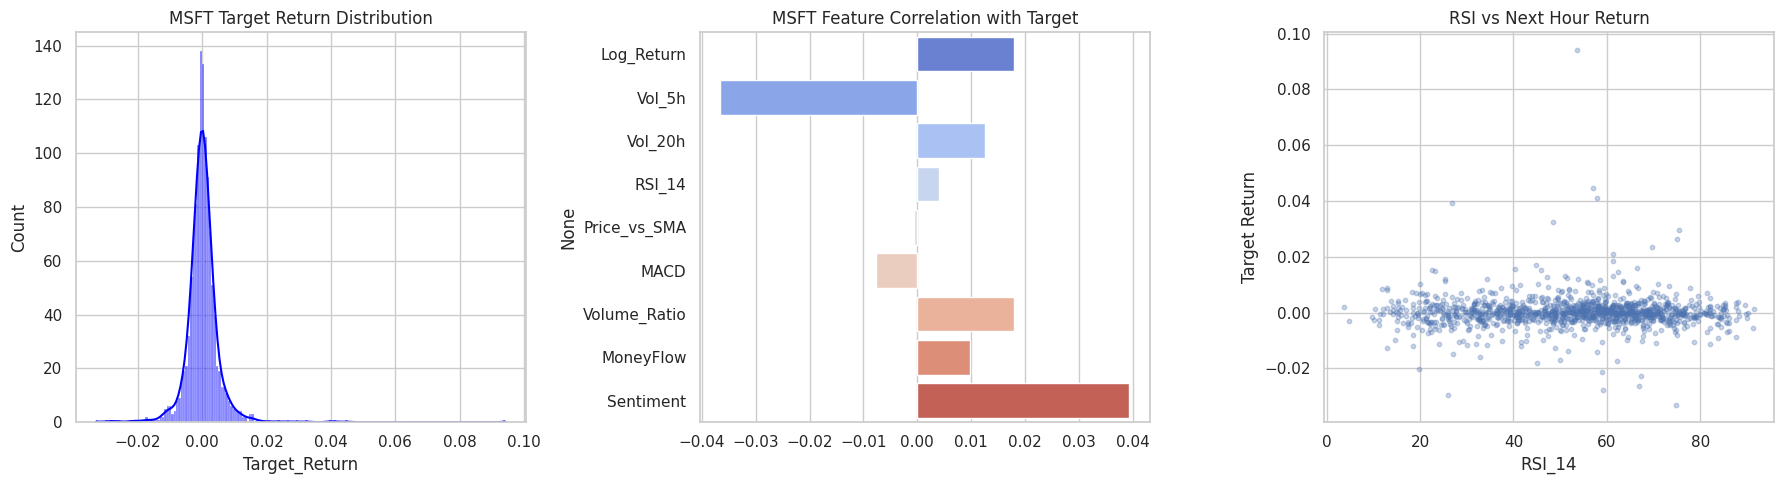

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: -0.0813 | RMSE: 0.00492 | AIC: -3872.0 | BIC: -3836.9
     Lasso | IC: nan | RMSE: 0.00487 | AIC: -3880.4 | BIC: -3845.2
     RF    | IC: 0.0071 | RMSE: 0.00579 | AIC: -3753.0 | BIC: -3717.8
     XGB   | IC: 0.0462 | RMSE: 0.00707 | AIC: -3606.9 | BIC: -3571.8

--------------------------------------------------------------------------------
🎯 ANALYZING: NVDA
--------------------------------------------------------------------------------
   > Generating EDA for NVDA...


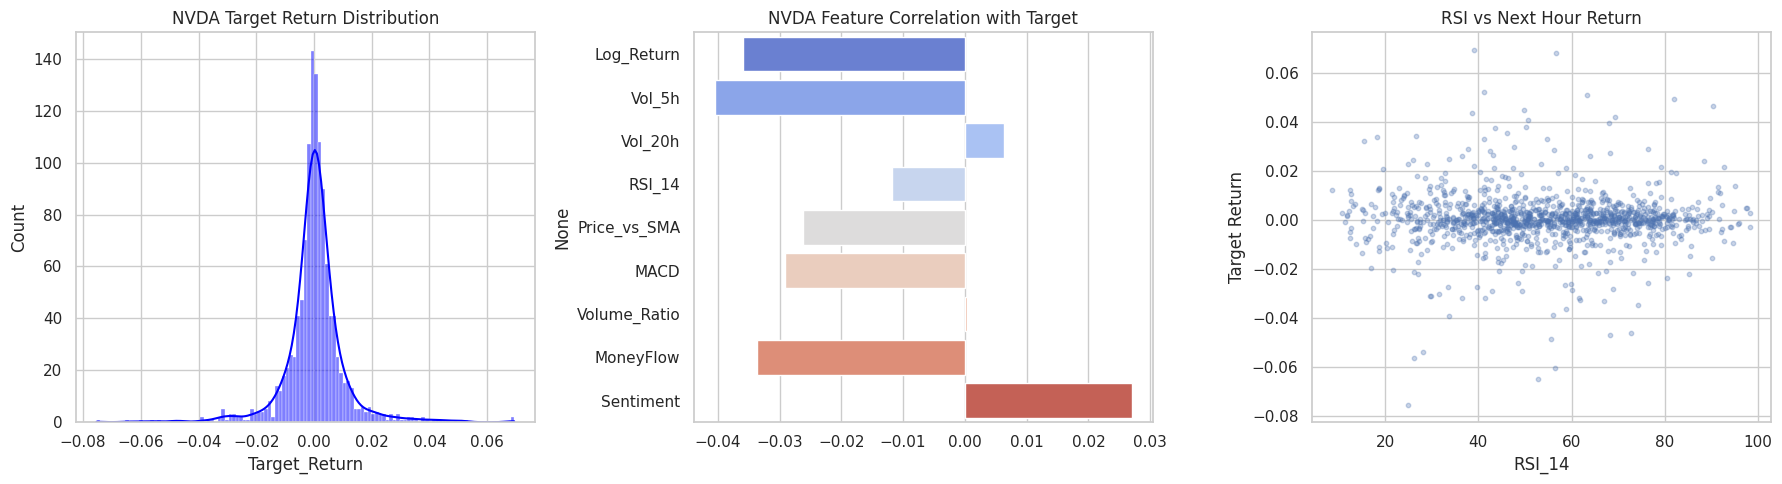

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: 0.0136 | RMSE: 0.01088 | AIC: -3291.5 | BIC: -3256.4
     Lasso | IC: nan | RMSE: 0.01080 | AIC: -3296.6 | BIC: -3261.5
     RF    | IC: -0.0047 | RMSE: 0.01127 | AIC: -3265.5 | BIC: -3230.3
     XGB   | IC: -0.0256 | RMSE: 0.01255 | AIC: -3186.8 | BIC: -3151.7

--------------------------------------------------------------------------------
🎯 ANALYZING: TSLA
--------------------------------------------------------------------------------
   > Generating EDA for TSLA...


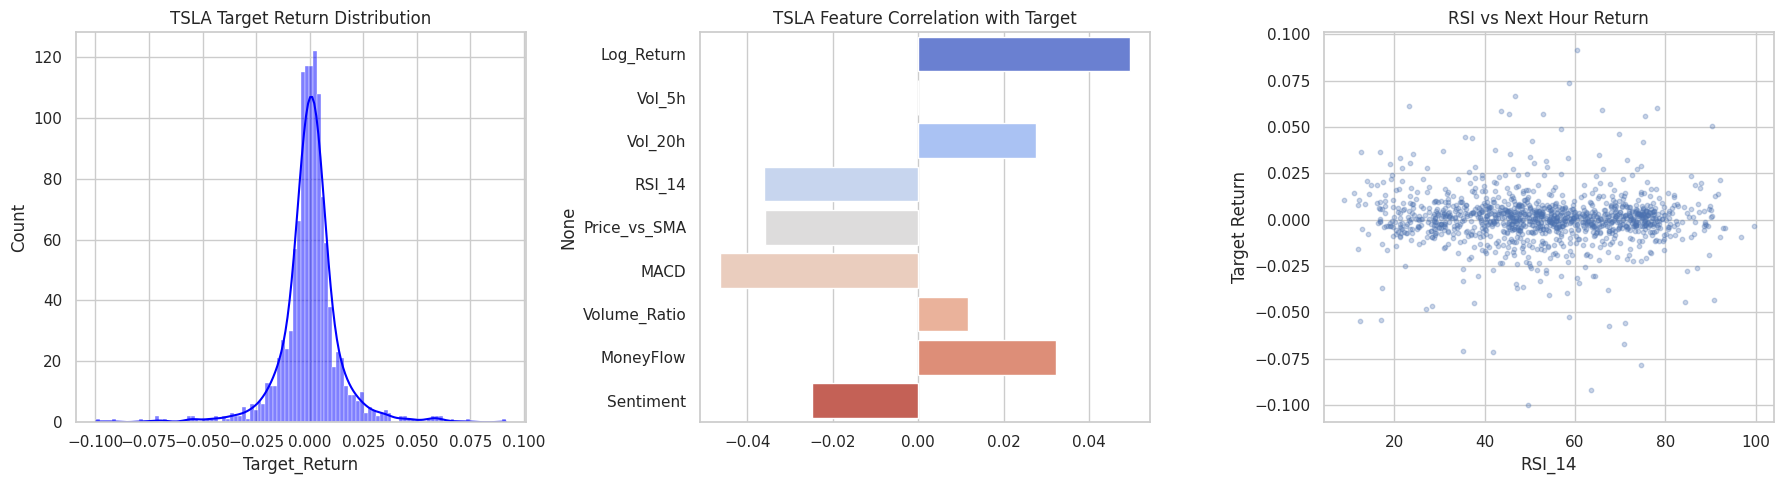

   Train: 851 | Test: 366
   > Tuning Models (GridSearch + TimeSeriesSplit)...
     Ridge | IC: 0.0228 | RMSE: 0.01201 | AIC: -3219.1 | BIC: -3184.0
     Lasso | IC: nan | RMSE: 0.01192 | AIC: -3224.3 | BIC: -3189.1
     RF    | IC: 0.0055 | RMSE: 0.01223 | AIC: -3205.8 | BIC: -3170.7
     XGB   | IC: 0.0063 | RMSE: 0.01195 | AIC: -3222.8 | BIC: -3187.7

🏆 STEP 3: FINAL LEADERBOARD
   Model   Mean_IC
0  Ridge  0.000595
1    XGB -0.008074
2     RF -0.019493

🎉 WINNER: Ridge


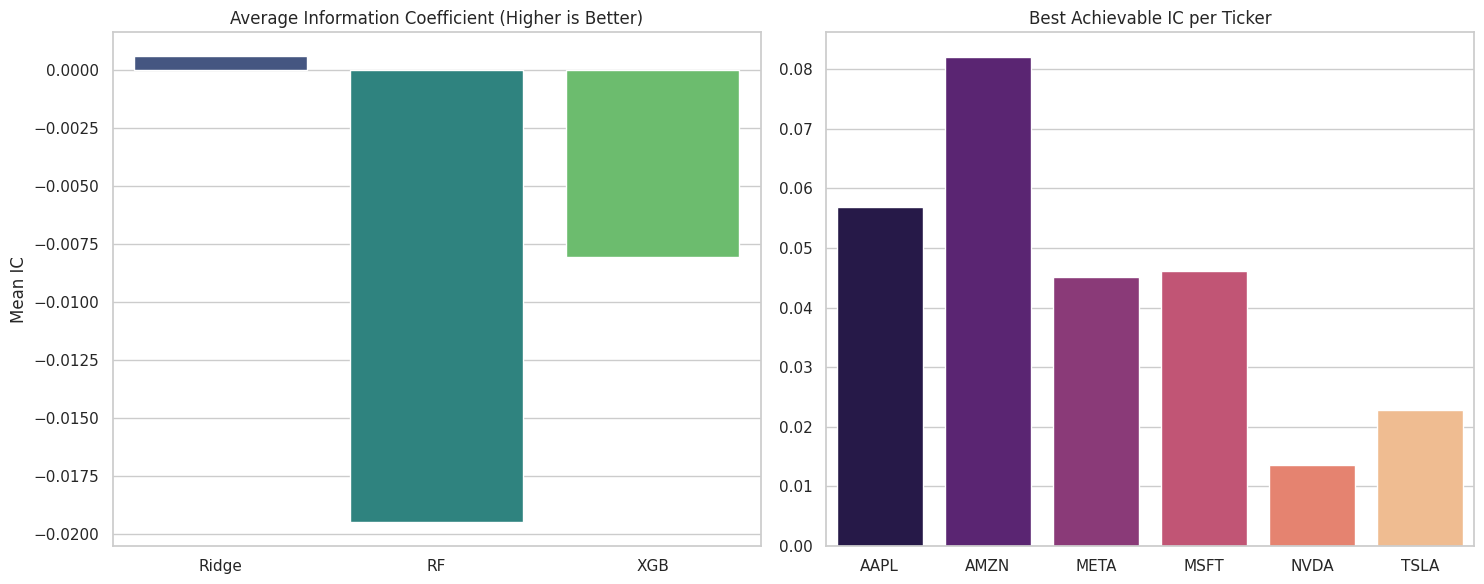


🔄 STEP 4: RETRAINING GLOBAL Ridge MODEL ON FULL DATASET...

✅ SAVED MODEL: Ridge_momentum_production.joblib
🚀 READY FOR DEPLOYMENT.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, make_scorer
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

# ==========================================
# 1. LOAD & GLOBAL EDA
# ==========================================
print("🔥 STEP 1: LOADING DATASET...")
FILE_PATH = "tech_stocks_1h_final_merged_safe.csv"

# Load & Parse
df_all = pd.read_csv(FILE_PATH)
df_all['Datetime'] = pd.to_datetime(df_all['Datetime'])
df_all = df_all.sort_values(['Ticker', 'Datetime'])

# Handle Column Mismatches (Safety Check)
if 'SentimentSignal' not in df_all.columns:
    cols = df_all.columns
    if 'Sentiment_Signal' in cols:
        df_all = df_all.rename(columns={'Sentiment_Signal': 'SentimentSignal'})
    else:
        df_all['SentimentSignal'] = 0.0

print(f"📊 Rows: {len(df_all)} | Tickers: {df_all['Ticker'].unique()}")
TICKERS = df_all['Ticker'].unique().tolist()

# Plot 1: Global Price Overview
print("\n>>> Generating Global Price Plot...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, ticker in enumerate(TICKERS[:6]):
    ax = axes[i//3, i%3]
    df_t = df_all[df_all['Ticker']==ticker]
    ax.plot(df_t['Datetime'], df_t['Close'], linewidth=1)
    ax.set_title(f"{ticker} Close Price")
plt.tight_layout()
plt.show()

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
def calculate_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi.fillna(50)

def calculate_aic_bic(y_true, y_pred, n_features):
    """Calculates AIC/BIC for Regression"""
    n = len(y_true)
    resid = y_true - y_pred
    sse = np.sum(resid**2)
    if sse == 0: return np.inf, np.inf

    aic = n * np.log(sse / n) + 2 * n_features
    bic = n * np.log(sse / n) + n_features * np.log(n)
    return aic, bic

def engineer_features(df_ticker):
    df = df_ticker.copy()

    # 1H AHEAD TARGET (MOMENTUM) -> Log Return of NEXT Hour
    df['Target_Return'] = np.log(df['Close'].shift(-1) / df['Close'])

    # --- FEATURES ---
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    # Volatility
    df['Vol_5h'] = df['Log_Return'].rolling(5).std()
    df['Vol_20h'] = df['Log_Return'].rolling(20).std()

    # Trend / Oscillators
    df['RSI_14'] = calculate_rsi(df['Close'])
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['Price_vs_SMA'] = df['Close'] / df['SMA_20'] - 1

    # MACD
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26

    # Volume & Sentiment
    df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(10).mean()
    df['MoneyFlow'] = df['Log_Return'] * df['Volume']
    df['Sentiment'] = df['SentimentSignal'].fillna(0)

    # --- CLEANUP ---
    feature_cols = ['Log_Return', 'Vol_5h', 'Vol_20h', 'RSI_14', 'Price_vs_SMA',
                    'MACD', 'Volume_Ratio', 'MoneyFlow', 'Sentiment']

    # Drop NaNs created by rolling windows & Target shift
    df_clean = df.dropna(subset=feature_cols + ['Target_Return']).copy()

    return df_clean.reset_index(drop=True), feature_cols

# ==========================================
# 3. PIPELINE SETUP (GridSearch Included)
# ==========================================
def get_model_pipeline(model_type):
    """Returns Pipeline & ParamGrid for Tuning"""

    base_steps = [
        ('imp', SimpleImputer(strategy='median')),
        ('scale', RobustScaler()),
        ('power', PowerTransformer())
    ]

    if model_type == 'Ridge':
        pipeline = Pipeline(base_steps + [('model', Ridge())])
        params = {'model__alpha': [0.1, 1.0, 10.0]}

    elif model_type == 'Lasso':
        pipeline = Pipeline(base_steps + [('model', Lasso())])
        params = {'model__alpha': [0.001, 0.01, 0.1]}

    elif model_type == 'RF':
        pipeline = Pipeline(base_steps + [('model', RandomForestRegressor(n_jobs=-1, random_state=42))])
        params = {'model__n_estimators': [100], 'model__max_depth': [5, 10]}

    elif model_type == 'XGB':
        pipeline = Pipeline(base_steps + [('model', xgb.XGBRegressor(n_jobs=-1, random_state=42, objective='reg:squarederror'))])
        params = {'model__n_estimators': [100], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5]}

    return pipeline, params

# Metric: Information Coefficient (Spearman Corr)
def information_coefficient(y_true, y_pred):
    score, _ = spearmanr(y_true, y_pred)
    return score

ic_scorer = make_scorer(information_coefficient, greater_is_better=True)

# ==========================================
# 4. MAIN TRAINING LOOP
# ==========================================
all_results = {}
global_ics = {'Ridge':[], 'Lasso':[], 'RF':[], 'XGB':[]}

print("\n🚀 STEP 2: STARTING TRAINING LOOP (Per-Ticker Tuning)...")

for ticker in TICKERS:
    print(f"\n{'-'*80}")
    print(f"🎯 ANALYZING: {ticker}")
    print(f"{'-'*80}")

    # 1. Filter Data
    df_t = df_all[df_all['Ticker'] == ticker].copy()
    if len(df_t) < 200:
        print("Skipping (Insufficient Data)")
        continue

    # 2. Engineer Features
    df_eng, features = engineer_features(df_t)
    X = df_eng[features]
    y = df_eng['Target_Return']

    # Plot 2: Ticker Specific EDA
    print(f"   > Generating EDA for {ticker}...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Target Dist
    sns.histplot(y, kde=True, ax=axes[0], color='blue')
    axes[0].set_title(f"{ticker} Target Return Distribution")

    # Correlation
    corr = df_eng[features + ['Target_Return']].corr()['Target_Return'][:-1]
    sns.barplot(x=corr.values, y=corr.index, ax=axes[1], palette='coolwarm')
    axes[1].set_title(f"{ticker} Feature Correlation with Target")

    # Feature vs Target (Scatter)
    axes[2].scatter(df_eng['RSI_14'], y, alpha=0.3, s=10)
    axes[2].set_xlabel("RSI_14")
    axes[2].set_ylabel("Target Return")
    axes[2].set_title("RSI vs Next Hour Return")

    plt.tight_layout()
    plt.show()

    # 3. Time Series Split (70/30) for FINAL Evaluation
    split_idx = int(len(X) * 0.70)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"   Train: {len(X_train)} | Test: {len(X_test)}")

    # 4. Train & Tune Models
    ticker_res = {}

    # Inner CV for Tuning
    tscv = TimeSeriesSplit(n_splits=3)

    print("   > Tuning Models (GridSearch + TimeSeriesSplit)...")
    for name in ['Ridge', 'Lasso', 'RF', 'XGB']:
        pipe, params = get_model_pipeline(name)

        # Grid Search with TimeSeriesSplit
        grid = GridSearchCV(pipe, params, cv=tscv, scoring=ic_scorer, n_jobs=-1)
        grid.fit(X_train, y_train)

        # Evaluate on Holdout Test Set
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        ic = information_coefficient(y_test, y_pred)
        aic, bic = calculate_aic_bic(y_test, y_pred, len(features))

        print(f"     {name:5} | IC: {ic:.4f} | RMSE: {rmse:.5f} | AIC: {aic:.1f} | BIC: {bic:.1f}")

        ticker_res[name] = {'IC': ic, 'RMSE': rmse, 'AIC': aic, 'BIC': bic, 'Best_Params': grid.best_params_}
        global_ics[name].append(ic)

    all_results[ticker] = ticker_res

# ==========================================
# 5. GLOBAL SELECTION & VISUALIZATION
# ==========================================
print("\n" + "="*80)
print("🏆 STEP 3: FINAL LEADERBOARD")
print("="*80)

global_stats = {}
for name, ics in global_ics.items():
    clean_ics = [x for x in ics if not np.isnan(x)]
    if clean_ics:
        global_stats[name] = np.mean(clean_ics)

sorted_models = sorted(global_stats.items(), key=lambda x: x[1], reverse=True)
global_best_name = sorted_models[0][0]

print(pd.DataFrame(sorted_models, columns=['Model', 'Mean_IC']))
print(f"\n🎉 WINNER: {global_best_name}")

# Plot 3: Final Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart
sns.barplot(x=list(global_stats.keys()), y=list(global_stats.values()), ax=axes[0], palette='viridis')
axes[0].set_title("Average Information Coefficient (Higher is Better)")
axes[0].set_ylabel("Mean IC")

# Best IC per Ticker
best_ic_per_ticker = {t: max([m['IC'] for m in res.values()]) for t, res in all_results.items()}
sns.barplot(x=list(best_ic_per_ticker.keys()), y=list(best_ic_per_ticker.values()), ax=axes[1], palette='magma')
axes[1].set_title("Best Achievable IC per Ticker")
plt.tight_layout()
plt.show()

# ==========================================
# 6. FINAL PRODUCTION RETRAINING
# ==========================================
print(f"\n🔄 STEP 4: RETRAINING GLOBAL {global_best_name} MODEL ON FULL DATASET...")

# Collect 100% of data (Train + Test)
X_full_list = []
y_full_list = []

for ticker in TICKERS:
    df_t = df_all[df_all['Ticker'] == ticker].copy()
    if len(df_t) < 200: continue

    df_eng, features = engineer_features(df_t)

    # APPEND EVERYTHING (No Split)
    X_full_list.append(df_eng[features])
    y_full_list.append(df_eng['Target_Return'])

X_final = pd.concat(X_full_list).reset_index(drop=True)
y_final = pd.concat(y_full_list).reset_index(drop=True)

# Train Final Model
final_pipe, final_params = get_model_pipeline(global_best_name)
# Fit on full data (Best generic configuration)
final_pipe.fit(X_final, y_final)

# Plot 4: Final Feature Importance
if global_best_name in ['RF', 'XGB']:
    print("\n>>> Generating Feature Importance Plot...")
    feat_imp = final_pipe.named_steps['model'].feature_importances_
    imp_df = pd.DataFrame({'Feature':features, 'Imp':feat_imp}).sort_values('Imp', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=imp_df, y='Feature', x='Imp', palette='cool')
    plt.title(f"Global Feature Importance ({global_best_name})")
    plt.tight_layout()
    plt.show()

# Save
filename = f"{global_best_name}_momentum_production.joblib"
joblib.dump({
    'model': final_pipe,
    'features': features,
    'description': f"Trained on {len(X_final)} rows. Target: 1h Log Return."
}, filename)

print(f"\n✅ SAVED MODEL: {filename}")
print(f"🚀 READY FOR DEPLOYMENT.")